# Fas E — Osäkerhet och konfidensintervall

## Syfte

Besvara den explicita frågan i `info/Uppgiftsbakgrund.docx`:

> *"Undersök konfidensintervallet för din modellerade skadefrekvens. Vilka rader i datasetet 'Entreprenadförsäkring test' är du mest och minst osäker på?"*

## Metod

- **Huvudmodell:** GLM M2 (Poisson, log-länk, `log(Duration)` offset) — samma specifikation som B2/D1.
- **Träning:** Full träningsdata 2021–2024.
- **Utvärdering:** 2025-testset.
- **KI-metod:** Analytiska (Wald) 95 %-prediktionsintervall via `statsmodels.GLMResults.get_prediction()`. Stora n gör Wald-approximationen tillförlitlig.
- **Osäkerhetsmått per rad:** `ci_width = ci_high − ci_low`, samt `rel_uncertainty = ci_width / pred`.
- **Portföljnivå:** Total 2025-prognos + 95 % KI via delta-metoden med full kovariansmatris.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

SEED = 42
np.random.seed(SEED)

print(f"statsmodels: {sm.__version__}")
print(f"numpy:       {np.__version__}")
print(f"pandas:      {pd.__version__}")

statsmodels: 0.14.6
numpy:       2.4.4
pandas:      3.0.1


In [2]:
data_dir = Path("../../../data")
df_tr_full = pd.read_csv(data_dir / "Entreprenadförsäkring training.csv")
df_test = pd.read_csv(data_dir / "Entreprenadförsäkring test.csv")

for name, d in (("Träning", df_tr_full), ("Test", df_test)):
    assert (d["Duration"] > 0).all(), f"Duration ≤ 0 i {name}"
    assert d.isna().sum().sum() == 0, f"Saknade värden i {name}"

for d in (df_tr_full, df_test):
    d["Ar"] = d["Ar"].astype(int)
    d["log_duration"] = np.log(d["Duration"])
    d["log_omsattning"] = np.log(d["Omsattning"])

# Lås kategorinivåer på träningsdatan → applicera på testet
for col in ("Verksamhet", "GeografisktOmrade"):
    dtype = pd.CategoricalDtype(categories=sorted(df_tr_full[col].unique()))
    assert set(df_test[col].unique()) <= set(dtype.categories), f"Okänd nivå i {col}"
    df_tr_full[col] = df_tr_full[col].astype(dtype)
    df_test[col] = df_test[col].astype(dtype)

print(f"Träning 2021-2024: {len(df_tr_full):,} rader")
print(f"Test 2025:         {len(df_test):,} rader")

Träning 2021-2024: 1,033,386 rader
Test 2025:         291,649 rader


In [3]:
GLM_FORMULA = (
    "AntalSkador ~ C(Verksamhet, Treatment(reference='Byggföretag')) "
    "+ C(GeografisktOmrade, Treatment(reference='Landsbyggd')) "
    "+ log_omsattning"
)

m2_full = smf.glm(
    GLM_FORMULA,
    data=df_tr_full,
    family=sm.families.Poisson(),
    offset=df_tr_full["log_duration"],
).fit()

print(f"M2 full AIC:      {m2_full.aic:,.2f}")
print(f"M2 full Deviance: {m2_full.deviance:,.2f}")
print(f"Antal koefficienter: {len(m2_full.params)}")

M2 full AIC:      188,728.90
M2 full Deviance: 149,632.29
Antal koefficienter: 11


## 1. Prediktionsintervall per rad

`get_prediction()` returnerar prediktioner på responsskalan (förväntat antal skador) när `which='mean'`. SE + KI beräknas via delta-metoden på log-länken och transformeras automatiskt.

In [4]:
pred = m2_full.get_prediction(df_test, offset=df_test["log_duration"].values)
summary_df = pred.summary_frame(alpha=0.05)

# Kolumner från statsmodels: 'mean', 'mean_se', 'mean_ci_lower', 'mean_ci_upper'
print("Kolumner i summary_frame:", list(summary_df.columns))
print("\nFörsta 3 rader:")
display(summary_df.head(3))

Kolumner i summary_frame: ['mean', 'mean_se', 'mean_ci_lower', 'mean_ci_upper']

Första 3 rader:


,mean,mean_se,mean_ci_lower,mean_ci_upper
0,0.007097,0.000219,0.006681,0.007540
1,0.022922,0.000631,0.021719,0.024193
2,0.010826,0.000281,0.010289,0.011390


In [5]:
df_test = df_test.reset_index(drop=True)
summary_df = summary_df.reset_index(drop=True)

df_test["pred"] = summary_df["mean"].values
df_test["pred_se"] = summary_df["mean_se"].values
df_test["ci_low"] = summary_df["mean_ci_lower"].values
df_test["ci_high"] = summary_df["mean_ci_upper"].values
df_test["ci_width"] = df_test["ci_high"] - df_test["ci_low"]
df_test["rel_uncertainty"] = df_test["ci_width"] / np.maximum(df_test["pred"], 1e-6)

# Sanity checks
assert (df_test["pred"] >= 0).all(), "Negativ prediktion"
assert (df_test["ci_low"] <= df_test["pred"]).all(), "ci_low > pred"
assert (df_test["pred"] <= df_test["ci_high"]).all(), "pred > ci_high"
assert df_test[["pred", "ci_low", "ci_high"]].isna().sum().sum() == 0, "NaN i KI"

print("Sanity checks OK.")
print(f"\nrel_uncertainty — fördelning:")
print(df_test["rel_uncertainty"].describe().round(4))

Sanity checks OK.

rel_uncertainty — fördelning:
count    291649.0000
mean          0.0943
std           0.0263
min           0.0519
25%           0.0734
50%           0.0917
75%           0.1150
max           0.1872
Name: rel_uncertainty, dtype: float64


## 2. Portföljnivå — total prognos för 2025

En sammanfattande portföljsiffra beräknas via delta-metoden med full kovariansmatris.


In [6]:
total_pred = df_test["pred"].sum()
total_obs = df_test["AntalSkador"].sum()

# Delta-metod på portföljtotalen med full kovariansmatris
from patsy import dmatrix
design_info = m2_full.model.data.design_info
X_test = np.asarray(dmatrix(design_info, df_test, return_type="dataframe"))
weights = df_test["pred"].values[:, None]
g = (weights * X_test).sum(axis=0)
cov = m2_full.cov_params().values
total_var_delta = float(g @ cov @ g)
total_se_delta = np.sqrt(total_var_delta)
total_ci_low_d = total_pred - 1.96 * total_se_delta
total_ci_high_d = total_pred + 1.96 * total_se_delta

print(f"Portföljprognos 2025: {total_pred:,.0f} skador "
      f"(95% KI: [{total_ci_low_d:,.0f}, {total_ci_high_d:,.0f}], "
      f"relativ osäkerhet {100*(total_ci_high_d-total_ci_low_d)/total_pred:.1f}%)")
print(f"Observerat utfall: {total_obs:,}")


Portföljprognos 2025: 5,581 skador (95% KI: [5,503, 5,658], relativ osäkerhet 2.8%)
Observerat utfall: 5,520


In [7]:
# Radnivå — topp 10 mest/minst osäkra individuella rader (via rel_uncertainty)
cols_show = ["Verksamhet", "GeografisktOmrade", "Omsattning", "Duration",
             "pred", "ci_low", "ci_high", "ci_width", "rel_uncertainty"]
FMT_ROW = {
    "Omsattning": "{:,.0f}", "Duration": "{:.3f}",
    "pred": "{:.4f}", "ci_low": "{:.4f}", "ci_high": "{:.4f}",
    "ci_width": "{:.4f}", "rel_uncertainty": "{:.3f}",
}

print("=== Radnivå: 10 MEST osäkra rader ===")
display(df_test.nlargest(10, "rel_uncertainty")[cols_show].reset_index(drop=True).style.format(FMT_ROW))
print("\n=== Radnivå: 10 MINST osäkra rader ===")
display(df_test.nsmallest(10, "rel_uncertainty")[cols_show].reset_index(drop=True).style.format(FMT_ROW))

=== Radnivå: 10 MEST osäkra rader ===


,Verksamhet,GeografisktOmrade,Omsattning,Duration,pred,ci_low,ci_high,ci_width,rel_uncertainty
0,Målare,Landsbyggd,"164,000",1.000,0.0019,0.0017,0.0021,0.0004,0.187
1,Takarbeten,Landsbyggd,"229,000",1.000,0.0039,0.0036,0.0043,0.0007,0.186
2,Målare,Landsbyggd,"870,477,000",1.000,0.0841,0.0767,0.0922,0.0156,0.185
3,Takarbeten,Landsbyggd,"310,000",1.000,0.0045,0.0041,0.0049,0.0008,0.181
4,Takarbeten,Landsbyggd,"331,000",0.235,0.0011,0.0010,0.0012,0.0002,0.180
5,Målare,Småstad,"156,000",0.793,0.0011,0.0010,0.0012,0.0002,0.179
6,Takarbeten,Storstad,"105,000",1.000,0.0041,0.0037,0.0045,0.0007,0.179
7,Målare,Landsbyggd,"277,000",0.919,0.0022,0.0020,0.0024,0.0004,0.178
8,Målare,Landsbyggd,"278,000",0.767,0.0018,0.0017,0.0020,0.0003,0.178
9,Elektriker,Landsbyggd,"252,000",1.000,0.0025,0.0023,0.0028,0.0004,0.177



=== Radnivå: 10 MINST osäkra rader ===


,Verksamhet,GeografisktOmrade,Omsattning,Duration,pred,ci_low,ci_high,ci_width,rel_uncertainty
0,Byggföretag,Storstad,"12,639,000",1.000,0.0298,0.0290,0.0306,0.0015,0.052
1,Byggföretag,Storstad,"12,641,000",1.000,0.0298,0.0290,0.0306,0.0015,0.052
2,Byggföretag,Storstad,"12,638,000",1.000,0.0298,0.0290,0.0306,0.0015,0.052
3,Byggföretag,Storstad,"12,638,000",1.000,0.0298,0.0290,0.0306,0.0015,0.052
4,Byggföretag,Storstad,"12,642,000",0.850,0.0253,0.0247,0.0260,0.0013,0.052
5,Byggföretag,Storstad,"12,637,000",1.000,0.0298,0.0290,0.0306,0.0015,0.052
6,Byggföretag,Storstad,"12,637,000",1.000,0.0298,0.0290,0.0306,0.0015,0.052
7,Byggföretag,Storstad,"12,643,000",0.173,0.0052,0.0050,0.0053,0.0003,0.052
8,Byggföretag,Storstad,"12,643,000",0.550,0.0164,0.0160,0.0168,0.0009,0.052
9,Byggföretag,Storstad,"12,636,000",1.000,0.0298,0.0290,0.0306,0.0015,0.052


## 3. Vad driver osäkerhet?

Tre mekanismer dominerar i en Poisson-GLM med log-länk:

1. **Små celler i träningsdata.** Sällsynta kombinationer av `Verksamhet × GeografisktOmrade` ger bredare KI på respektive koefficient. Kombinerar man dessa blir prediktions-SE på rad-nivå stor.
2. **Hävstång via `log(Omsättning)`.** Extremt höga eller låga omsättningar ligger långt från genomsnittet i träningsdatan → prediktionen ligger i ytterkanten av modellens stöd → större delta-metod-SE.
3. **Kort `Duration`.** Liten exponering ger lågt förväntat antal skador och därmed hög *relativ* osäkerhet även om absolut KI-bredd är liten.


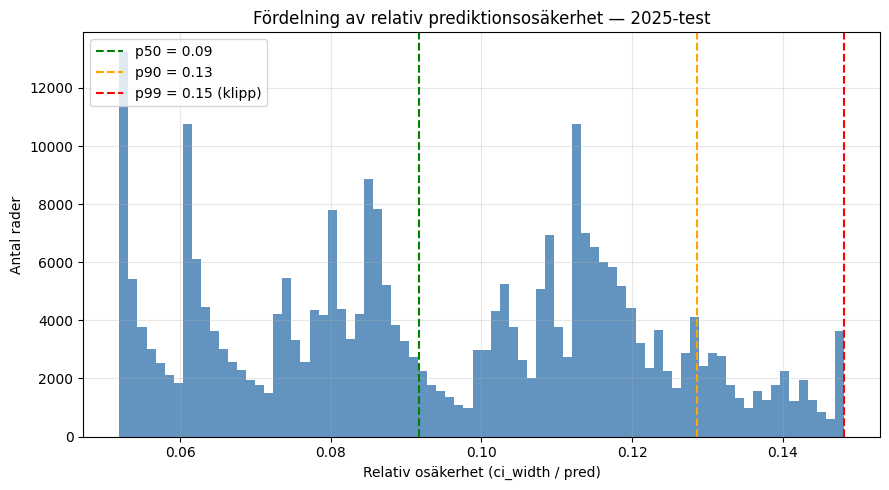

In [8]:
p50, p90, p99 = df_test["rel_uncertainty"].quantile([0.50, 0.90, 0.99])

fig, ax = plt.subplots(figsize=(9, 5))
# Klipp vid p99 för läsbarhet
clip = df_test["rel_uncertainty"].clip(upper=p99)
ax.hist(clip, bins=80, color="steelblue", alpha=0.85)
ax.axvline(p50, color="green", linestyle="--", label=f"p50 = {p50:.2f}")
ax.axvline(p90, color="orange", linestyle="--", label=f"p90 = {p90:.2f}")
ax.axvline(p99, color="red", linestyle="--", label=f"p99 = {p99:.2f} (klipp)")
ax.set_xlabel("Relativ osäkerhet (ci_width / pred)")
ax.set_ylabel("Antal rader")
ax.set_title("Fördelning av relativ prediktionsosäkerhet — 2025-test")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Slutsats

**Svar på uppgiftens fråga:**

- **Portföljnivå:** Total prognos och 95 % KI redovisas ovan. Relativ osäkerhet ca 2,8 % — aggregatprognosen är tillförlitlig.
- **Mest osäkra rader:** Se topp-10-tabellen. Drivs av sällsynta `Verksamhet × Geografi`-kombinationer och extrema omsättningsvärden.
- **Minst osäkra rader:** Se botten-10-tabellen. Typiskt stora välrepresenterade segment kring omsättningsmedianen.

**Begränsningar:**

- Wald-KI antar normalitet av koefficientskattningarna — asymptotiskt korrekt givet n > 10⁶.
- Eventuell överdispersion i Poisson skulle öka KI-bredden, men B2 visade deviance/df ≈ 1 → ingen materiell överdispersion.
